In [1]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [4]:
PROJECT_ROOT = Path("../../")

DATA_DIR = PROJECT_ROOT / "data"

ECHONET_DIR = DATA_DIR / "EchoNet-Dynamic"

VIDEOS_DIR = ECHONET_DIR / "Videos"

FILELIST_PATH = ECHONET_DIR / "FileList.csv"

In [5]:
filelist = pd.read_csv(FILELIST_PATH)

print("Dataset Shape:", filelist.shape)

filelist.head()

Dataset Shape: (10030, 9)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [6]:
print(filelist.columns.tolist())

['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split']


In [7]:
filelist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10030 entries, 0 to 10029
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FileName        10030 non-null  object 
 1   EF              10030 non-null  float64
 2   ESV             10030 non-null  float64
 3   EDV             10030 non-null  float64
 4   FrameHeight     10030 non-null  int64  
 5   FrameWidth      10030 non-null  int64  
 6   FPS             10030 non-null  int64  
 7   NumberOfFrames  10030 non-null  int64  
 8   Split           10030 non-null  object 
dtypes: float64(3), int64(4), object(2)
memory usage: 705.4+ KB


In [8]:
filelist.isnull().sum()

FileName          0
EF                0
ESV               0
EDV               0
FrameHeight       0
FrameWidth        0
FPS               0
NumberOfFrames    0
Split             0
dtype: int64

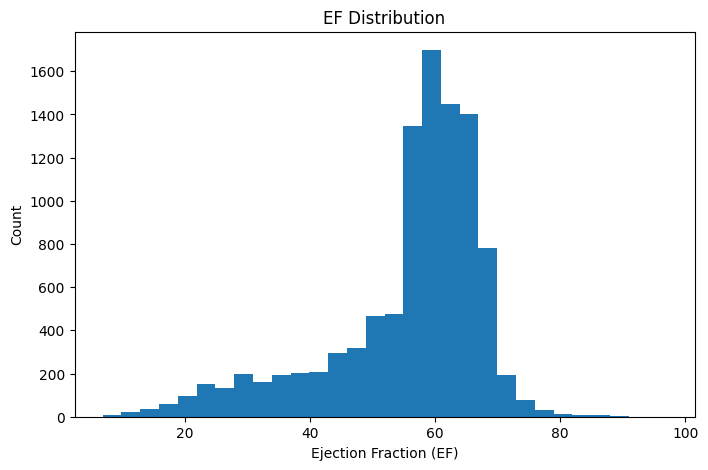

In [9]:
plt.figure(figsize=(8,5))

plt.hist(filelist["EF"], bins=30)

plt.xlabel("Ejection Fraction (EF)")

plt.ylabel("Count")

plt.title("EF Distribution")

plt.show()

In [10]:
print("Minimum EF:", filelist["EF"].min())

print("Maximum EF:", filelist["EF"].max())

print("Mean EF:", filelist["EF"].mean())

print("Median EF:", filelist["EF"].median())

Minimum EF: 6.907258122
Maximum EF: 96.96723658
Mean EF: 55.748248101920346
Median EF: 59.209108924999995


In [11]:
def ef_to_severity(ef):
    
    if ef >= 50:
        return "Normal"
    
    elif ef >= 40:
        return "Mild"
    
    else:
        return "Severe"

In [12]:
filelist["Severity"] = filelist["EF"].apply(ef_to_severity)

filelist[["EF", "Severity"]].head()

,EF,Severity
0,78.498406,Normal
1,59.101988,Normal
2,62.363798,Normal
3,54.545097,Normal
4,24.887742,Severe


In [13]:
filelist["Severity"].value_counts()

Severity
Normal    7784
Severe    1264
Mild       982
Name: count, dtype: int64

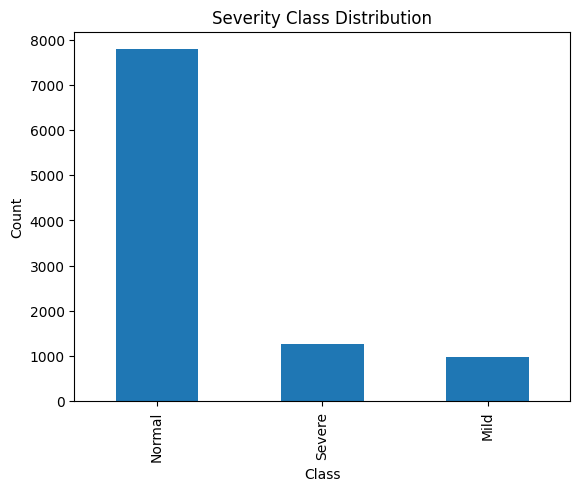

In [14]:
filelist["Severity"].value_counts().plot(kind="bar")

plt.title("Severity Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

medical classification analysis

In [30]:
random_sample = filelist.sample(1).iloc[0]

video_name = str(random_sample["FileName"]).strip()+".avi"

video_path = VIDEOS_DIR / video_name

print(video_path)

print("Exists:", video_path.exists())

../../data/EchoNet-Dynamic/Videos/0X673B5192D6B9C4EA.avi
Exists: True


In [32]:
cap = cv2.VideoCapture(str(video_path))

print("Opened Successfully:", cap.isOpened())

Opened Successfully: True


In [33]:
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

print("Total Frames:", total_frames)

print("Frame Width:", frame_width)

print("Frame Height:", frame_height)

print("FPS:", fps)

Total Frames: 182
Frame Width: 112
Frame Height: 112
FPS: 50.0


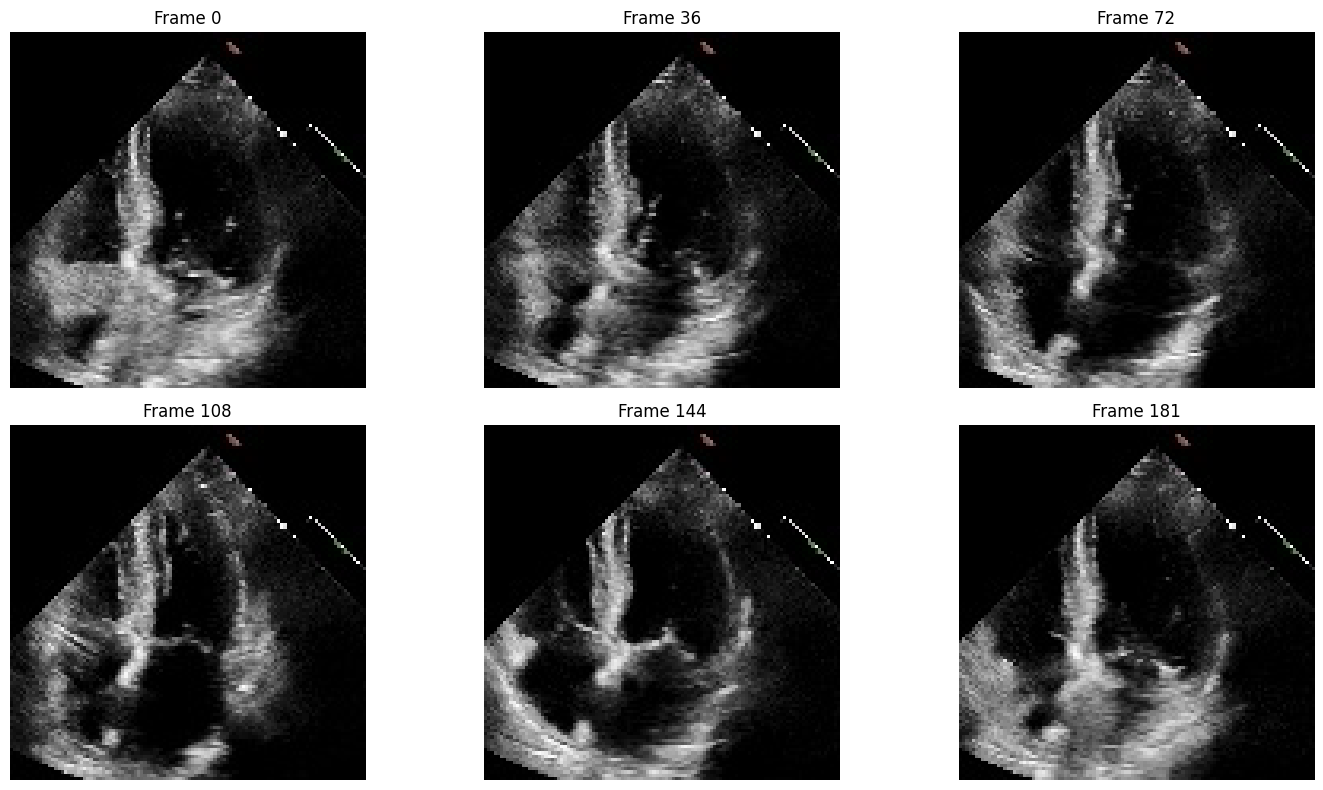

In [34]:
frame_indices = np.linspace(0, total_frames - 1, 6, dtype=int)

plt.figure(figsize=(15,8))

for i, idx in enumerate(frame_indices):

    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

    ret, frame = cap.read()

    if not ret:
        continue

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)

    plt.imshow(frame_rgb)

    plt.title(f"Frame {idx}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [35]:
cap.release()

print("Video released successfully")

Video released successfully


In [37]:
filelist["Split"].value_counts()

Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64

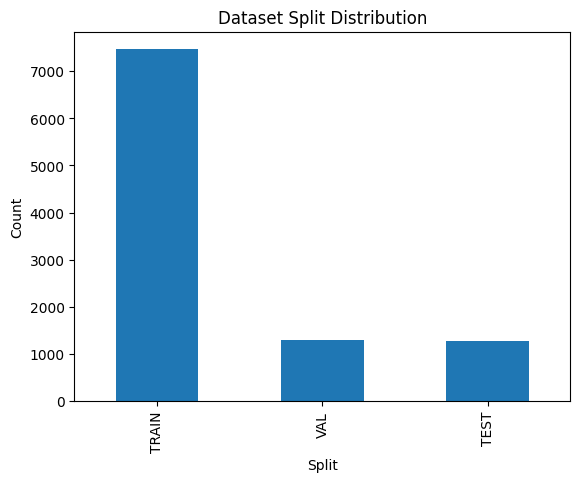

In [38]:
filelist["Split"].value_counts().plot(kind="bar")

plt.title("Dataset Split Distribution")

plt.xlabel("Split")

plt.ylabel("Count")

plt.show()

In [41]:
normal_cases = filelist[filelist["Severity"] == "Normal"]

mild_cases = filelist[filelist["Severity"] == "Mild"]

severe_cases = filelist[filelist["Severity"] == "Severe"]

print("Normal:", len(normal_cases))

print("Mild:", len(mild_cases))

print("Severe:", len(severe_cases))

Normal: 7784
Mild: 982
Severe: 1264


In [42]:
lowest_ef = filelist.sort_values("EF")[["FileName", "EF"]]

lowest_ef.head(10)

,FileName,EF
1259,0X1FBF4879584835DC,6.907258
7333,0X67A1EB7C88B5A510,7.719653
9221,0X7E46A5FDB773F2FC,8.775265
5886,0X56772AFC64BB2E21,8.911745
2892,0X333986F8FA0EE679,9.411372
933,0X1B8FD7CA891CA2CD,9.482447
2435,0X2DE6FC105DDE8B38,9.554068
5505,0X51EBAEFBADEB15E9,9.643794
505,0X166BF85033848E4E,9.729765
4719,0X4889B480C7F3DE83,10.047611


In [43]:
highest_ef = filelist.sort_values("EF", ascending=False)[["FileName", "EF"]]

highest_ef.head(10)

,FileName,EF
3092,0X354B37A25C64276F,96.967237
9544,0XA20EE6C5B1F48CB,90.312721
1249,0X1F9F3763AB755914,88.142061
5974,0X57AF4D24B154C573,87.361531
197,0X12430512E2BBCD55,86.908157
4386,0X44C18287CA978438,86.891774
7195,0X65E605F203321860,86.757974
3880,0X3EB0FC2695B0AB5F,86.009684
4500,0X46024CC33D00D4C6,85.679342
9480,0X973E4A9DAADDF9F,85.252871


In [44]:
frame_counts = []

sampled_rows = filelist.sample(100, random_state=42)

In [46]:
for _, row in sampled_rows.iterrows():

    video_name = str(row["FileName"]).strip() + ".avi"

    video_path = VIDEOS_DIR / video_name

    cap = cv2.VideoCapture(str(video_path))

    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_counts.append(frames)

    cap.release()

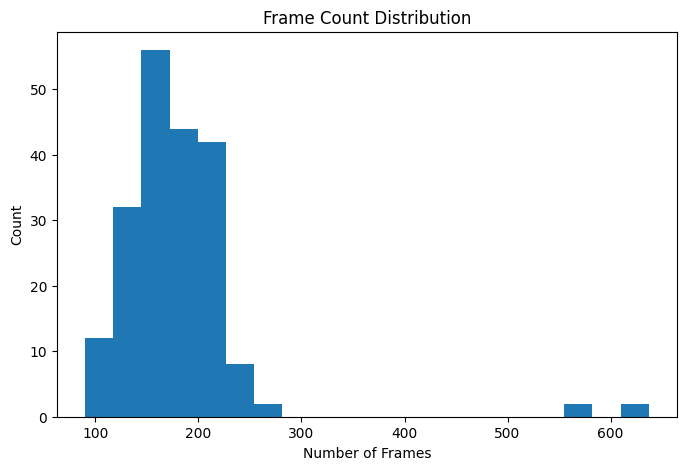

In [47]:
plt.figure(figsize=(8,5))

plt.hist(frame_counts, bins=20)

plt.title("Frame Count Distribution")

plt.xlabel("Number of Frames")

plt.ylabel("Count")

plt.show()

In [48]:
resolutions = []

sampled_rows = filelist.sample(100, random_state=42)

In [49]:
for _, row in sampled_rows.iterrows():

    video_name = str(row["FileName"]).strip() + ".avi"

    video_path = VIDEOS_DIR / video_name

    cap = cv2.VideoCapture(str(video_path))

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    resolutions.append((width, height))

    cap.release()

In [50]:
set(resolutions)

{(112, 112)}

In [58]:
print("01_dataset_exploration.ipynb completed successfully")

01_dataset_exploration.ipynb completed successfully
